<a href="https://colab.research.google.com/github/Infranape1/AI_Music_Genre_Classification/blob/master/Music_Genre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# STEP 1 — Setup Google Colab Environment

!pip install librosa
!pip install numpy pandas matplotlib seaborn scikit-learn tensorflow

In [ ]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
# STEP 2 — Load GTZAN Dataset

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/GTZAN/genres_original"

In [ ]:
genres = os.listdir(DATASET_PATH)
print(genres)

['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [ ]:
# STEP 3 — Dataset Analysis

genre_count = {}

for genre in genres:
    path = os.path.join(DATASET_PATH, genre)
    genre_count[genre] = len(os.listdir(path))

df = pd.DataFrame(list(genre_count.items()), columns=['Genre','Count'])
print(df)

       Genre  Count
0      blues    100
1  classical    100
2    country    100
3      disco    100
4     hiphop    100
5       jazz    100
6      metal    100
7        pop    100
8     reggae    100
9       rock    100


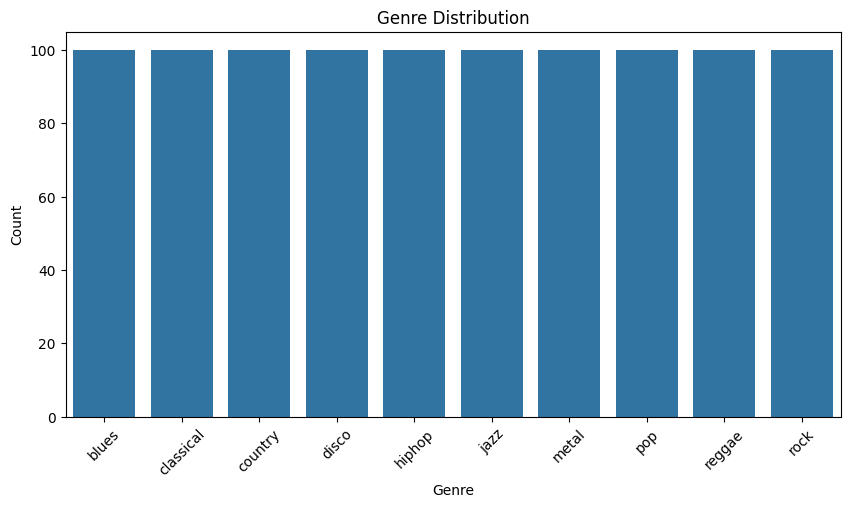

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x="Genre", y="Count", data=df)
plt.xticks(rotation=45)
plt.title("Genre Distribution")
plt.show()

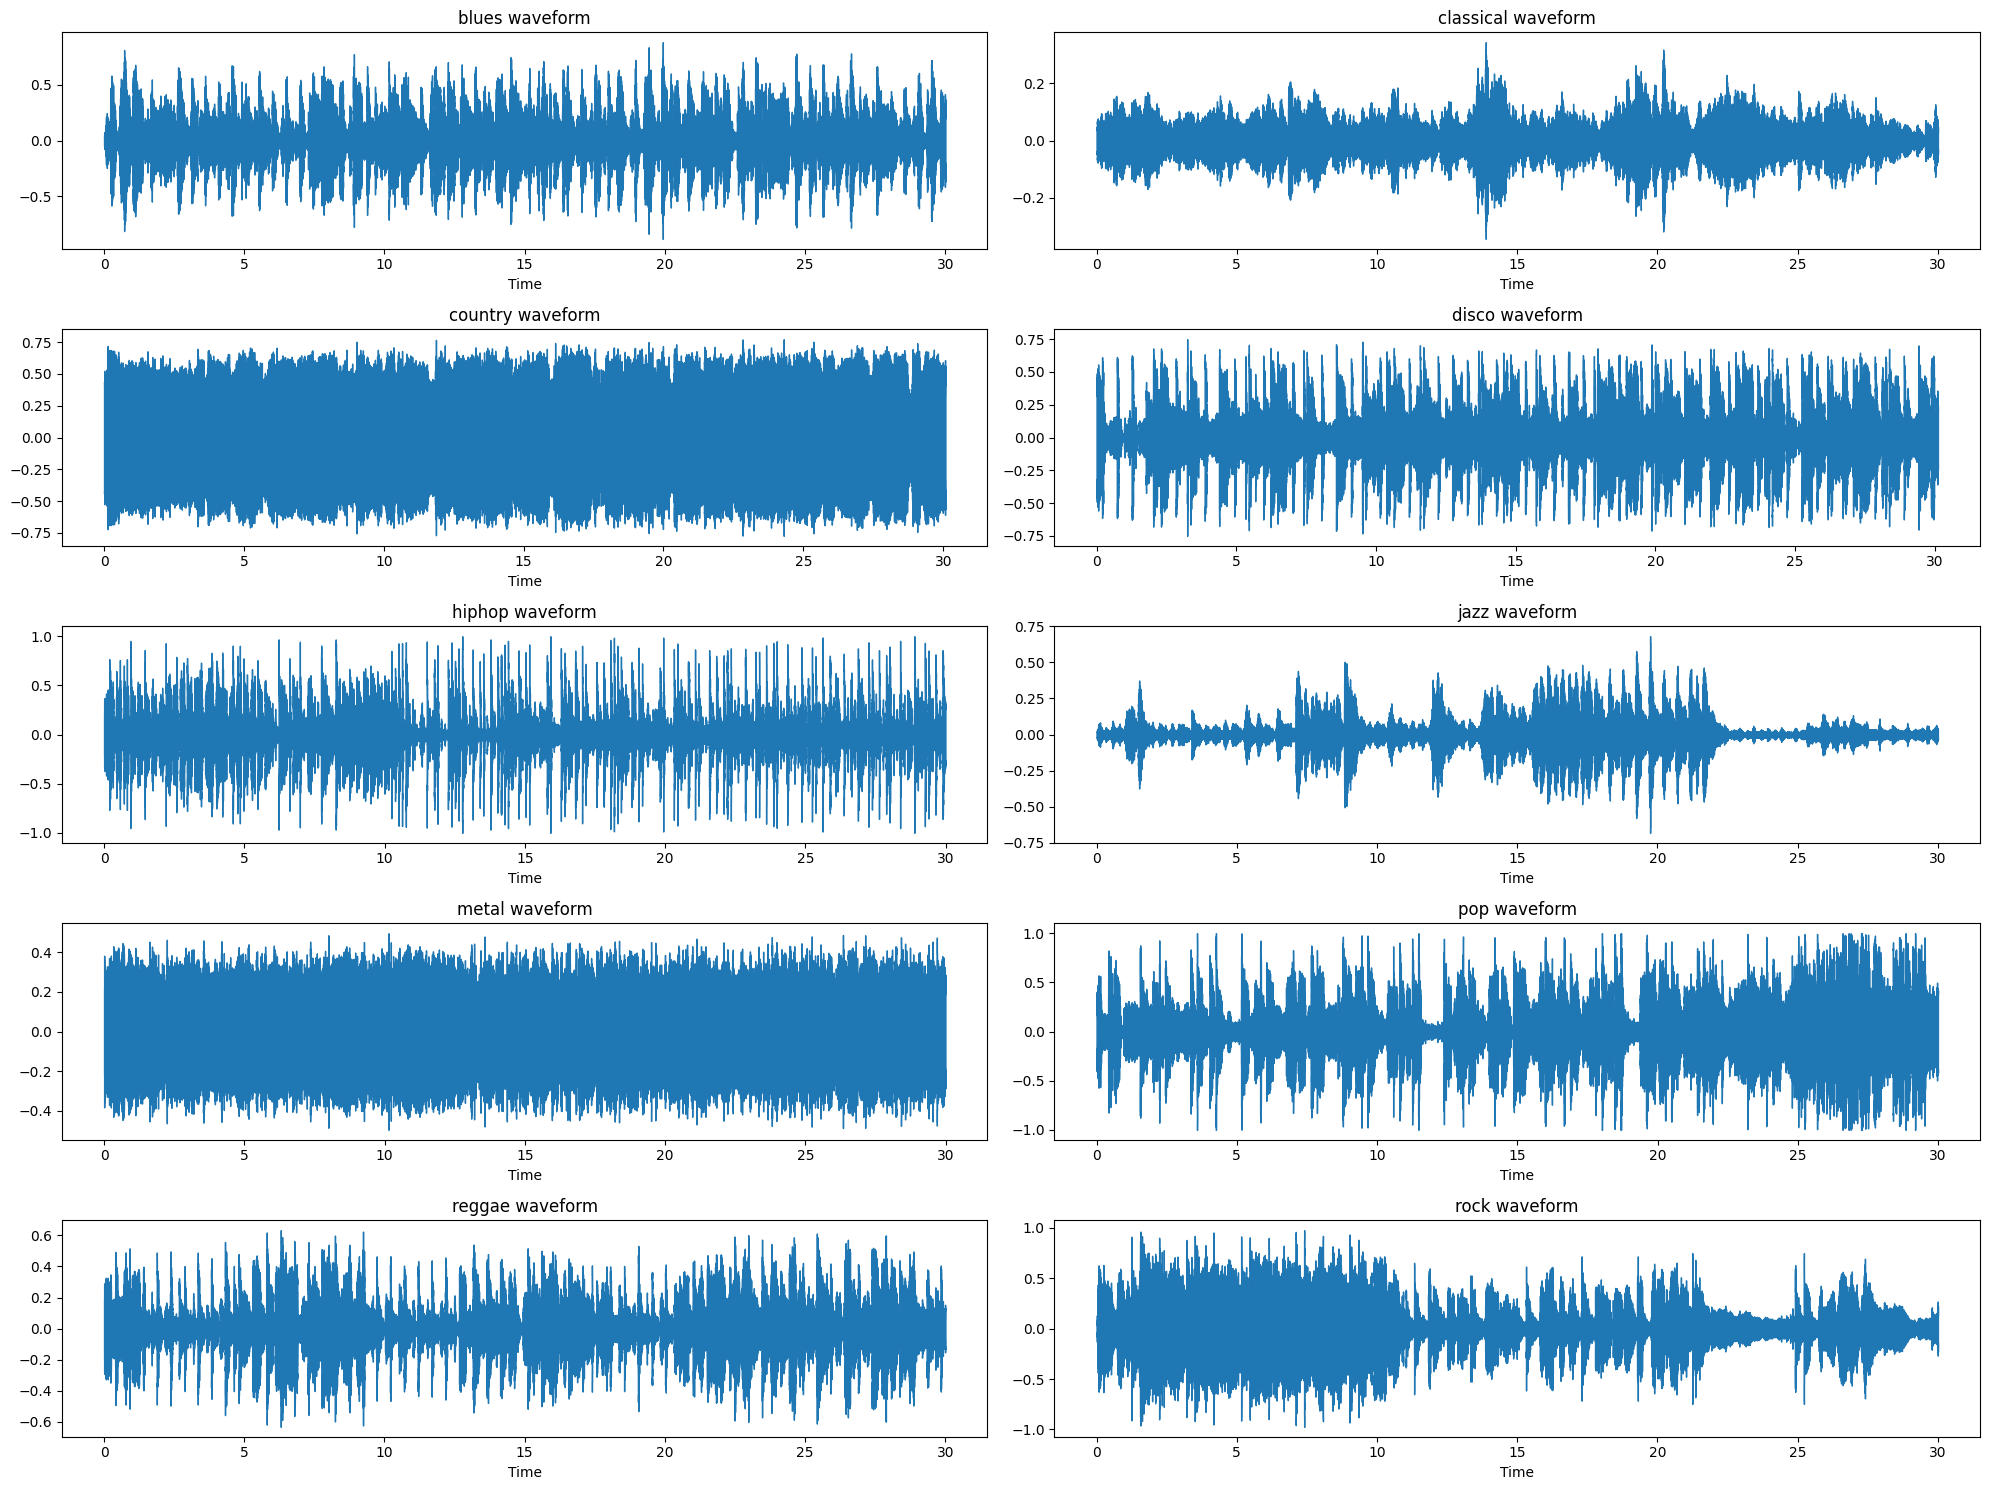

In [ ]:
# STEP 4 — Visualize Audio Waveform

import librosa
import librosa.display
import matplotlib.pyplot as plt
import os

DATASET_PATH = "/content/drive/MyDrive/GTZAN/genres_original"

genres = os.listdir(DATASET_PATH)

plt.figure(figsize=(20,15))

for i, genre in enumerate(genres):

    file_path = os.path.join(DATASET_PATH, genre, os.listdir(os.path.join(DATASET_PATH, genre))[0])

    y, sr = librosa.load(file_path)

    plt.subplot(5,2,i+1)

    librosa.display.waveshow(y, sr=sr)

    plt.title(f"{genre} waveform")

plt.tight_layout()
plt.show()

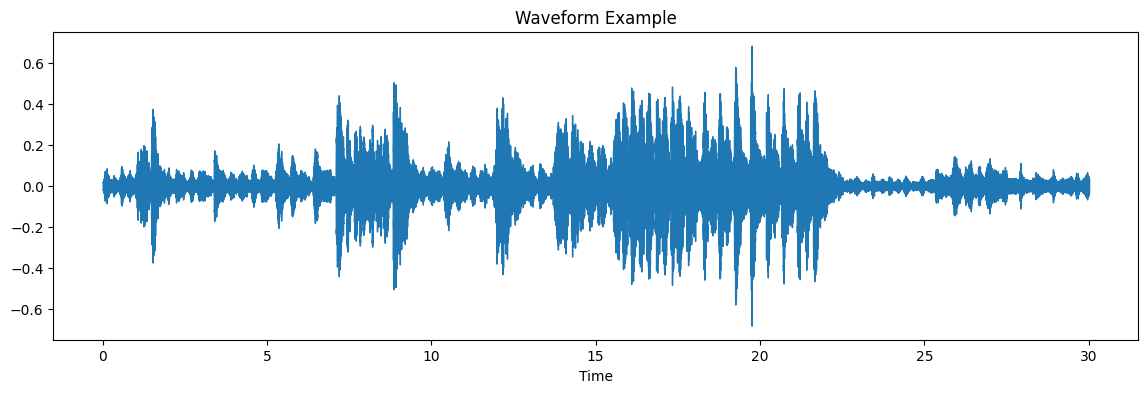

In [ ]:
file = DATASET_PATH + "/jazz/jazz.00000.wav"

y, sr = librosa.load(file)

plt.figure(figsize=(14,4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform Example")
plt.show()

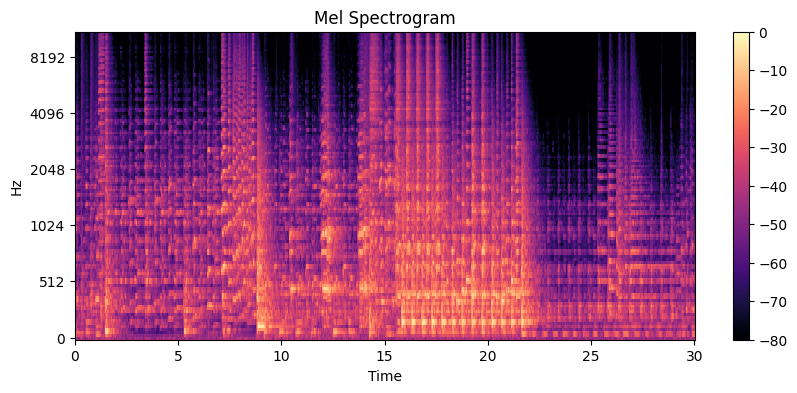

In [ ]:
# STEP 5 — Spectrogram Visualization

import librosa.display

y, sr = librosa.load(file)

spectrogram = librosa.feature.melspectrogram(y=y, sr=sr)

spectrogram_db = librosa.power_to_db(spectrogram, ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(spectrogram_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

In [ ]:
# STEP 6 — Extract MFCC Features

SAMPLE_RATE = 22050
TRACK_DURATION = 30
SAMPLES_PER_TRACK = SAMPLE_RATE * TRACK_DURATION

NUM_SEGMENTS = 10
SAMPLES_PER_SEGMENT = int(SAMPLES_PER_TRACK / NUM_SEGMENTS)

In [ ]:
def extract_features(dataset_path):

    data = {
        "mfcc": [],
        "labels": []
    }

    for i, genre in enumerate(os.listdir(dataset_path)):

        genre_path = os.path.join(dataset_path, genre)

        for file in os.listdir(genre_path):

            file_path = os.path.join(genre_path, file)

            try:
                signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
            except Exception as e:
                print("Skipping file:", file_path)
                continue

            for s in range(NUM_SEGMENTS):

                start = SAMPLES_PER_SEGMENT * s
                finish = start + SAMPLES_PER_SEGMENT

                mfcc = librosa.feature.mfcc(
                    y=signal[start:finish],
                    sr=sr,
                    n_mfcc=13
                )

                mfcc = mfcc.T

                if len(mfcc) == 130:
                    data["mfcc"].append(mfcc)
                    data["labels"].append(i)

    return data

In [ ]:
data = extract_features(DATASET_PATH)

X = np.array(data["mfcc"])
y = np.array(data["labels"])

print(X.shape)
print(y.shape)

/tmp/ipykernel_422/3239533499.py:17: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Skipping file: /content/drive/MyDrive/GTZAN/genres_original/jazz/jazz.00054.wav
(9986, 130, 13)
(9986,)


In [ ]:
# STEP 7 — Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(X_train.shape)
print(X_test.shape)

(7988, 130, 13, 1)
(1998, 130, 13, 1)


In [ ]:
# STEP 8 — CNN Model (Improved)

from tensorflow.keras import models, layers
from tensorflow.keras.layers import Input

model = models.Sequential()

model.add(Input(shape=(130,13,1)))

model.add(layers.Conv2D(32,(3,3),activation='relu',padding='same'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.BatchNormalization())

model.add(layers.Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.BatchNormalization())

model.add(layers.Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(layers.MaxPooling2D((2,1)))
model.add(layers.BatchNormalization())

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.3))

model.add(layers.Dense(10,activation='softmax'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=40,
    batch_size=32
)

Epoch 1/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 145ms/step - accuracy: 0.3533 - loss: 1.8228 - val_accuracy: 0.4840 - val_loss: 1.4064
Epoch 2/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 146ms/step - accuracy: 0.4850 - loss: 1.4188 - val_accuracy: 0.5766 - val_loss: 1.2090
Epoch 3/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 42s 152ms/step - accuracy: 0.5533 - loss: 1.2320 - val_accuracy: 0.5936 - val_loss: 1.1109
Epoch 4/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 141ms/step - accuracy: 0.6224 - loss: 1.0729 - val_accuracy: 0.6306 - val_loss: 1.1081
Epoch 5/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 45s 159ms/step - accuracy: 0.6597 - loss: 0.9668 - val_accuracy: 0.7142 - val_loss: 0.8483
Epoch 6/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 145ms/step - accuracy: 0.7019 - loss: 0.8390 - val_accuracy: 0.6977 - val_loss: 0.8977
Epoch 7/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 145ms/step - accuracy: 0.7451 - loss: 0.7218 - val_accuracy: 0.7447 - val_loss: 0.7603
Epoch 8/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 145ms/step - accuracy: 0.7887 - loss: 0

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 130, 13, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 65, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 65, 6, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 65, 6, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 3, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 3, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 3, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 3, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 3, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6144)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       786,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,643,360 (10.08 MB)

 Trainable params: 880,970 (3.36 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 1,761,942 (6.72 MB)

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8318 - loss: 0.9752
Test Accuracy: 0.8318318128585815


63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step


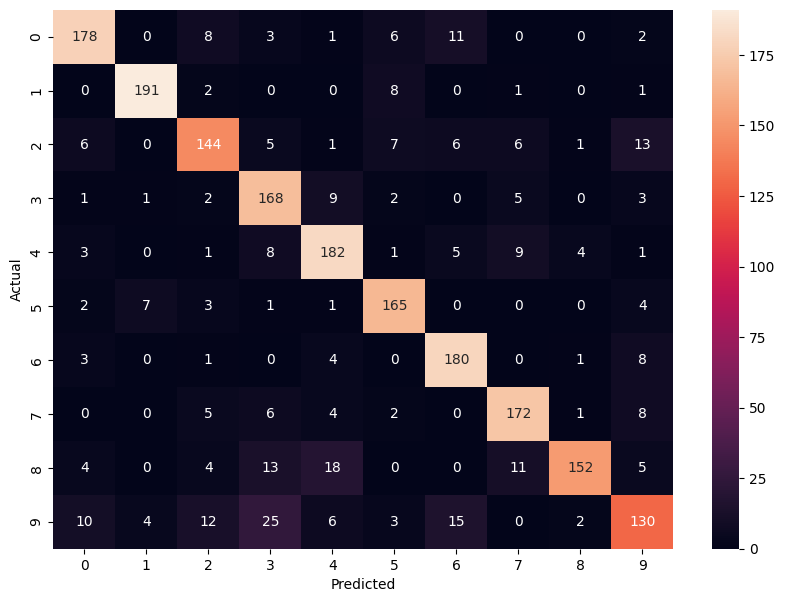

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# STEP 9 — Save the Trained Model (.h5)

model.save("music_genre_cnn.h5")

from google.colab import files
files.download("music_genre_cnn.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# STEP 10 — Save Genre Label Encoder (.pkl)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

genre_list = [
'blues','classical','country','disco',
'hiphop','jazz','metal','pop','reggae','rock'
]

le.fit(genre_list)

LabelEncoder()

In [ ]:
import pickle

with open("label_encoder.pkl","wb") as f:
    pickle.dump(le,f)

files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>